In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#데이터 리스트: X,Y
data = np.array([[45,3], [9,12],
                [15,10], [60,5],
                [21,15]])

data

array([[45,  3],
       [ 9, 12],
       [15, 10],
       [60,  5],
       [21, 15]])

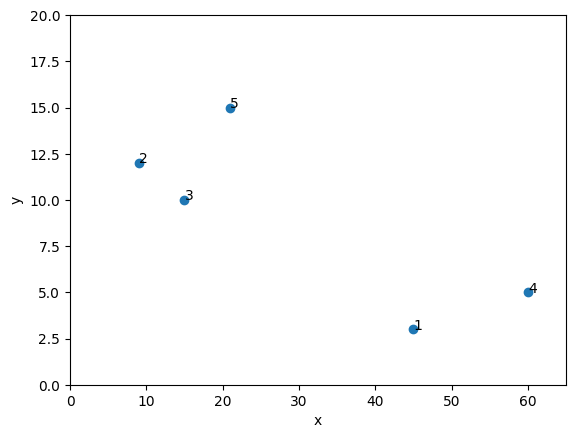

In [8]:
#원데이터 산포도 x,y
plt.scatter(data[:,0], data[:,1])
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0,65)
plt.ylim(0,20)

#행과 열의 수
rows, columns = data.shape
#데이터 라벨
for i in range(rows) :
  plt.annotate(i+1, (data[i,0], data[i,1]))

In [13]:
# 피처 스케일링 - 데이터 표준화
scaler = StandardScaler()
scaler.fit(data)
data_std = scaler.transform(data)
print(data_std)

[[ 0.77521709 -1.35526185]
 [-1.08530393  0.67763093]
 [-0.77521709  0.22587698]
 [ 1.55043418 -0.9035079 ]
 [-0.46513025  1.35526185]]


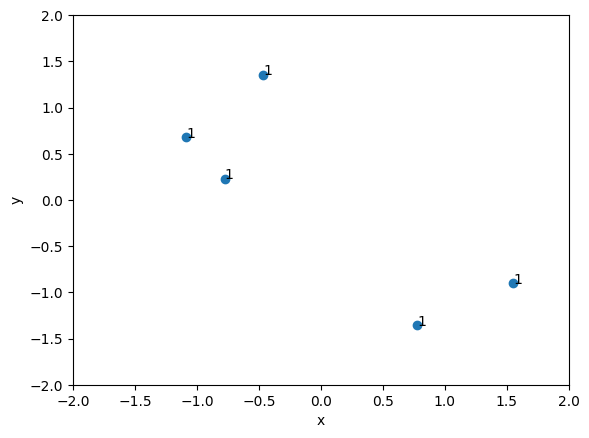

In [15]:
# 표준화 데이터의 X, Y 산포도
plt.scatter(data_std[:,0], data_std[:,1])
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-2,2)
plt.ylim(-2,2)

#행과 열의 수
rows, columns = data_std.shape
#데이터 라벨
for i in range(rows):
  plt.annotate(1, (data_std[i,0], data_std[i,1]))

In [21]:
# 군집의 수를 2개로 하는 군집화 객체
K=2
kmeans = KMeans(n_clusters=K)
# 군집화
kmeans.fit(data_std)
# 군집라벨
print(kmeans.labels_)
#군별별 군집 중심
print(kmeans.cluster_centers_)

[0 1 1 0 1]
[[ 1.16282564 -1.12938488]
 [-0.77521709  0.75292325]]


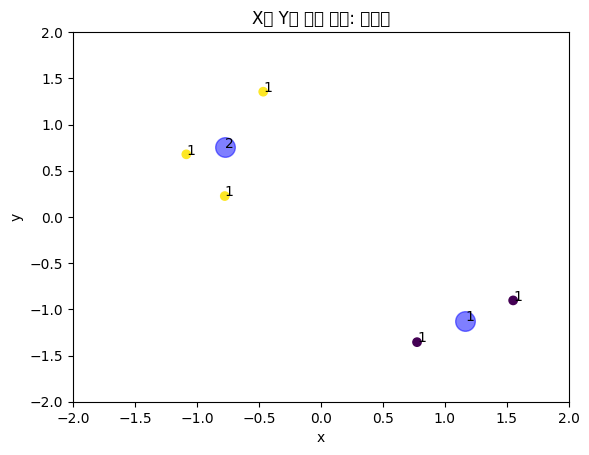

In [19]:
#군집 데이터 분포
plt.scatter(data_std[:,0], data_std[:,1], c=kmeans.labels_)

plt.title('X와 Y에 대한 분포: 표준화')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-2,2)
plt.ylim(-2,2)

# 행과 열의 수
rows, columns = data_std.shape
# 데이터 라벨
for i in range(rows):
  plt.annotate(1, (data_std[i,0], data_std[i,1]))

# 군집 중심표시
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            c='blue', s=200, alpha=0.5)
# 군집라벨
for k in range(0, K):
  plt.annotate(k+1, (kmeans.cluster_centers_[k,0], kmeans.cluster_centers_[k,1]))

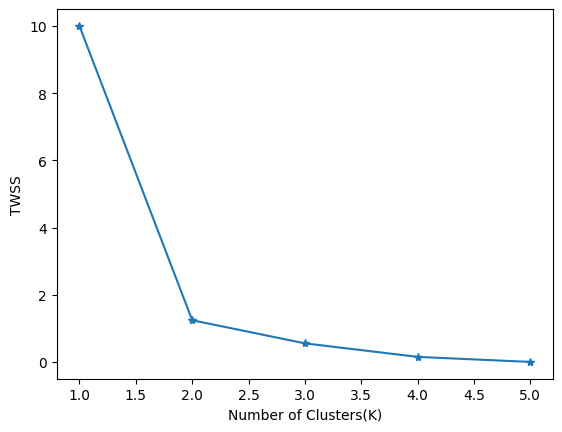

In [22]:
#클러스터 수에 따른 twss값
TWSS = {}
#군집 수 1~5까지 반복
for k in range(1, 6):
  # 군집 수 설정과 군집화 객체 생성
  model = KMeans(n_clusters=k)
  # 표준화된 X, Y 데이터에 대한 군집화
  model.fit(data_std)
  # 군집 수별 TWSS 값 저장
  TWSS[k] = model.inertia_

# 군집 수에 따른 TWSS 그래프
plt.plot(list(TWSS.keys()), list(TWSS.values()), marker='*')
plt.xlabel('Number of Clusters(K)')
plt.ylabel('TWSS')
plt.show()

In [25]:
TWSS

TWSS.keys()

TWSS.values()

dict_values([10.0, 1.2410877812663528, 0.5526393249607536, 0.15011773940345371, 0.0])

In [26]:
new_data_points = np.array([[25, 8], [50, 18], [35, 1]])
data = np.append(data, new_data_points, axis=0)
print(data)

[[45  3]
 [ 9 12]
 [15 10]
 [60  5]
 [21 15]
 [25  8]
 [50 18]
 [35  1]]


[1 0 0 1 0 0 0 1]
[[-0.5043822   0.65185737]
 [ 0.84063701 -1.08642895]]


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missin

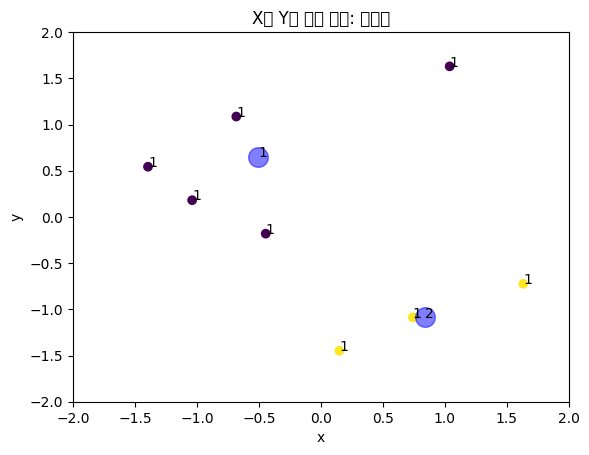

In [33]:
# 군집의 수를 2개로 하는 군집화 객체
K=2
kmeans = KMeans(n_clusters=K)
# 군집화
kmeans.fit(data_std)
# 군집라벨
print(kmeans.labels_)
#군별별 군집 중심
print(kmeans.cluster_centers_)

#군집 데이터 분포
plt.scatter(data_std[:,0], data_std[:,1], c=kmeans.labels_)

plt.title('X와 Y에 대한 분포: 표준화')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-2,2)
plt.ylim(-2,2)

# 행과 열의 수
rows, columns = data_std.shape
# 데이터 라벨
for i in range(rows):
  plt.annotate(1, (data_std[i,0], data_std[i,1]))

# 군집 중심표시
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            c='blue', s=200, alpha=0.5)
# 군집라벨
for k in range(0, K):
  plt.annotate(k+1, (kmeans.cluster_centers_[k,0], kmeans.cluster_centers_[k,1]))


# scaler = StandardScaler()
# scaler.fit(data)
# data_std = scaler.transform(data)
# print(data_std)

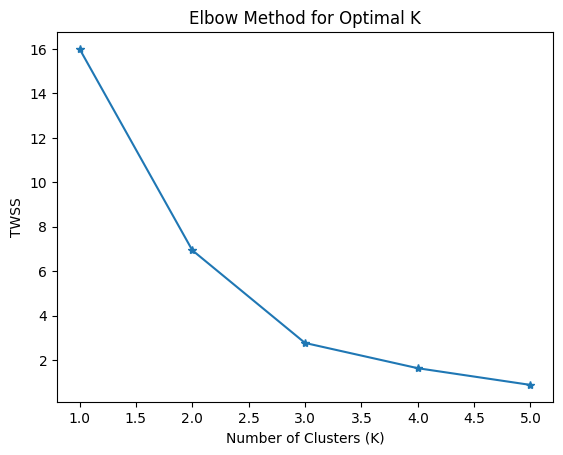

In [34]:
plt.plot(list(TWSS.keys()), list(TWSS.values()), marker='*')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('TWSS')
plt.title('Elbow Method for Optimal K')
plt.show()